importing dictionaries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
df = pd.read_csv("/content/Netflix.csv")
df.shape

(200, 12)

In [11]:
df.isnull().sum()/len(df)*100

,0
show_id,0.0
type,0.0
title,0.0
director,31.5
cast,10.0
country,32.0
date_added,0.0
release_year,0.0
rating,0.0
duration,0.0


In [12]:
# 1. Fill Categorical missing values
# We can do this in one line by passing a dictionary!
df.fillna({'director': 'Unknown', 'cast': 'Unknown', 'country': 'Unknown'}, inplace=True)

# 2. Drop the tiny amount of missing rows and make a clean copy
df = df.dropna(subset=['date_added', 'rating']).copy()

# 3. Convert date_added
# We add errors='coerce' just in case there are weird strings
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# Check if it worked
print(df.isnull().sum())
print(df.dtypes)

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object


/tmp/ipykernel_1788/3764547271.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')


In [13]:
df['year_added'] = df['date_added'].dt.year
df.shape

(200, 13)

In [14]:
# 1. Split 'duration' into two separate columns: number and unit
df[['duration_number', 'duration_unit']] = df['duration'].str.split(' ', expand=True)

# 2. Convert the number part to a numeric integer type
df['duration_number'] = pd.to_numeric(df['duration_number'])

# Filter only movies and calculate the mean duration
avg_movie_duration = df[df['duration_unit'] == 'min']['duration_number'].mean()
print(f"average movie duration: {avg_movie_duration} min")

average movie duration: 106.2755905511811 min


In [15]:
# 1. Count the types (Movies vs TV Shows)
type_counts = df['type'].value_counts()
print("Count of Movies vs TV Shows:")
print(type_counts)

# Percentage breakdown
type_percentages = df['type'].value_counts(normalize=True) * 100
print("percentage breakdown of movies vs TV shows:")
print(type_percentages)

# 3. The Genre Challenge: Explode and find the Top 10 Genres
# Split comma-separated strings into lists, then explode into separate rows
top_genres = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)
print("\nTop 10 Genres on Netflix:")
print(top_genres)

Count of Movies vs TV Shows:
type
Movie      127
TV Show     73
Name: count, dtype: int64
percentage breakdown of movies vs TV shows:
type
Movie      63.5
TV Show    36.5
Name: proportion, dtype: float64

Top 10 Genres on Netflix:
listed_in
Dramas                    45
International Movies      42
Comedies                  41
Action & Adventure        40
International TV Shows    31
Kids' TV                  22
TV Comedies               20
Thrillers                 17
TV Dramas                 16
Romantic Movies           15
Name: count, dtype: int64


/tmp/ipykernel_1788/1112778697.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


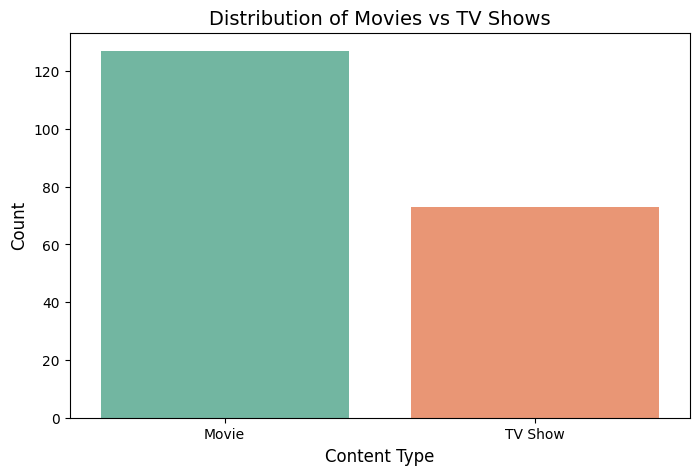

In [16]:
# Chart 1 - Movies vs TV Shows
plt.figure(figsize=(8, 5))

sns.countplot(x='type', data=df, palette='Set2')

plt.title("Distribution of Movies vs TV Shows", fontsize=14)
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

# plt.tight_layout()
plt.show()

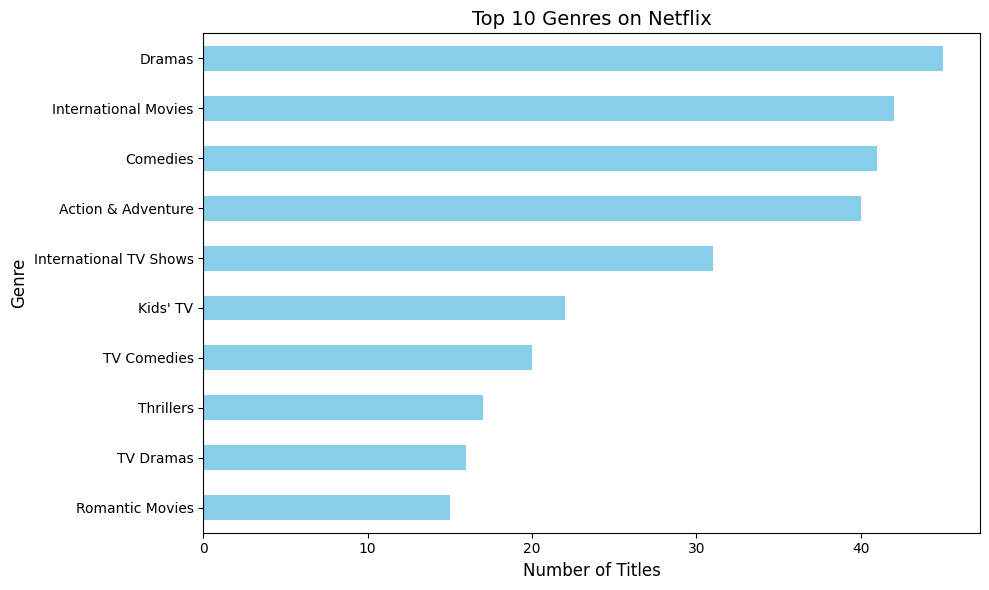

In [17]:
plt.figure(figsize=(10, 6))

top_genres.plot(kind='barh', color='skyblue')

plt.title("Top 10 Genres on Netflix", fontsize=14)
plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

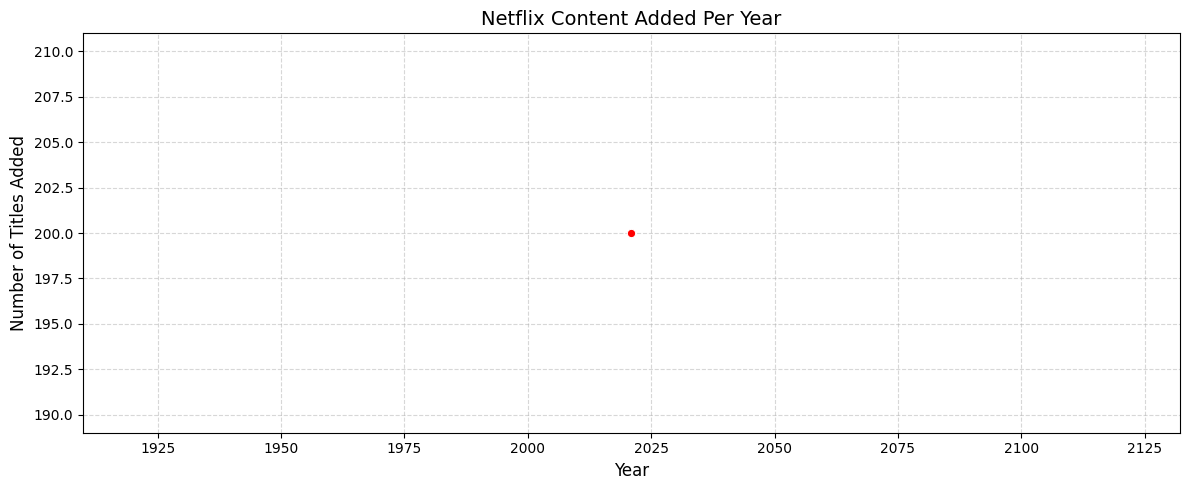

In [21]:
# 1. Clean and convert date_added properly
df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year

# 2. Count content per year and sort chronologically
content_per_year = df['year_added'].value_counts().sort_index()

# 3. Plot the multi-year trend line
plt.figure(figsize=(12, 5))
sns.lineplot(
    x=content_per_year.index,
    y=content_per_year.values,
    marker='o',
    color='red'
)

plt.title("Netflix Content Added Per Year", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Titles Added", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1788/2073160268.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating',


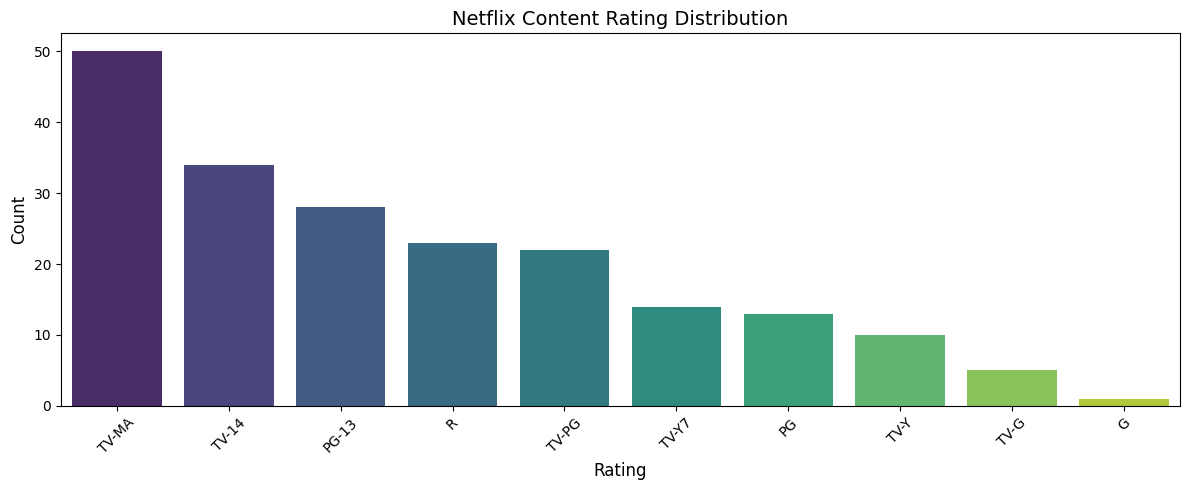

In [19]:
plt.figure(figsize=(12, 5))

sns.countplot(x='rating',
              data=df,
              order=df['rating'].value_counts().index,
              palette='viridis')

plt.title("Netflix Content Rating Distribution", fontsize=14)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()